# 🔧 Notebook 2: Preprocesamiento de Datos
## Dataset: Medical Cost Personal Dataset

**Objetivo:** Limpiar el dataset, codificar variables categóricas y escalar variables numéricas para preparar los datos para el modelado.

**Pasos:**
1. Limpieza de datos (duplicados, tipos, outliers opcionales)
2. Codificación de variables categóricas (One-Hot Encoding)
3. Escalamiento de variables numéricas (StandardScaler)
4. División train/test estratificada
5. Guardado de artefactos de preprocesamiento

In [1]:
# ─────────────────────────────────────────
# IMPORTACIONES
# ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 1. Carga y Revisión Inicial

In [2]:
# Carga del dataset original
df = pd.read_csv('../data/raw/insurance.csv')
print(f'📦 Shape original: {df.shape}')
print(f'📋 Columnas: {list(df.columns)}')
df.head(5)

📦 Shape original: (1338, 7)
📋 Columnas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Limpieza de Datos

In [3]:
# ─────────────────────────────────────────
# 2.1 DUPLICADOS
# ─────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'🔍 Registros duplicados: {n_dup}')

if n_dup > 0:
    print('⚠️ Eliminando duplicados...')
    df = df.drop_duplicates()
    print(f'✅ Shape tras eliminar duplicados: {df.shape}')
else:
    print('✅ Sin duplicados')

# 2.2 TIPOS DE DATOS
print('\n📊 Tipos de datos:')
print(df.dtypes)

# 2.3 VALORES FALTANTES
print('\n🔍 Valores faltantes por columna:')
print(df.isnull().sum())

# 2.4 VALIDACIONES DE RANGO
print('\n📊 Validación de rangos:')
print(f'  age: min={df.age.min()}, max={df.age.max()}  (esperado: 18-64)')
print(f'  bmi: min={df.bmi.min():.1f}, max={df.bmi.max():.1f}  (esperado: >10)')
print(f'  charges: min={df.charges.min():.2f}, max={df.charges.max():.2f}  (esperado: >0)')
print(f'  children: valores únicos → {sorted(df.children.unique())}')

🔍 Registros duplicados: 1
⚠️ Eliminando duplicados...
✅ Shape tras eliminar duplicados: (1337, 7)

📊 Tipos de datos:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

🔍 Valores faltantes por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

📊 Validación de rangos:
  age: min=18, max=64  (esperado: 18-64)
  bmi: min=16.0, max=53.1  (esperado: >10)
  charges: min=1121.87, max=63770.43  (esperado: >0)
  children: valores únicos → [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [4]:
# ─────────────────────────────────────────
# 2.5 NORMALIZACIÓN DE TEXTO (categorías)
# ─────────────────────────────────────────
for col in ['sex', 'smoker', 'region']:
    df[col] = df[col].str.lower().str.strip()

print('✅ Valores únicos normalizados:')
for col in ['sex', 'smoker', 'region']:
    print(f'  {col}: {df[col].unique().tolist()}')

✅ Valores únicos normalizados:
  sex: ['female', 'male']
  smoker: ['yes', 'no']
  region: ['southwest', 'southeast', 'northwest', 'northeast']


## 3. Ingeniería de Características Base (Feature Engineering Previo)

In [5]:
# ─────────────────────────────────────────
# FEATURES DE INTERACCIÓN (detectadas en EDA)
# ─────────────────────────────────────────
df_processed = df.copy()

# 1. Interacción BMI × Smoker (muy predictiva según EDA)
df_processed['bmi_smoker'] = df_processed['bmi'] * (df_processed['smoker'] == 'yes').astype(int)

# 2. Interacción Age × Smoker
df_processed['age_smoker'] = df_processed['age'] * (df_processed['smoker'] == 'yes').astype(int)

# 3. Categoría de BMI (según OMS)
df_processed['bmi_category'] = pd.cut(
    df_processed['bmi'],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=['underweight', 'normal', 'overweight', 'obese']
)

# 4. Grupo etario
df_processed['age_group'] = pd.cut(
    df_processed['age'],
    bins=[0, 30, 45, 100],
    labels=['young', 'middle', 'senior']
)

# 5. Log transform del target (para reg. lineal)
df_processed['log_charges'] = np.log1p(df_processed['charges'])

print(f'✅ Shape con nuevas features: {df_processed.shape}')
print('\n📋 Nuevas columnas agregadas:')
new_cols = ['bmi_smoker', 'age_smoker', 'bmi_category', 'age_group', 'log_charges']
print(df_processed[new_cols].head(5))

✅ Shape con nuevas features: (1337, 12)

📋 Nuevas columnas agregadas:
   bmi_smoker  age_smoker bmi_category age_group  log_charges
0        27.9          19   overweight     young     9.734236
1         0.0           0        obese     young     7.453882
2         0.0           0        obese     young     8.400763
3         0.0           0       normal    middle     9.998137
4         0.0           0   overweight    middle     8.260455


## 4. Codificación de Variables Categóricas

In [6]:
# ─────────────────────────────────────────
# ONE-HOT ENCODING
# ─────────────────────────────────────────
# Identificar columnas categóricas a codificar
cat_cols_ohe = ['sex', 'region', 'bmi_category', 'age_group']
binary_cols = ['smoker']  # Label encoding (binaria)

# Label encoding para smoker (binaria)
df_processed['smoker_enc'] = (df_processed['smoker'] == 'yes').astype(int)
print('📊 smoker → smoker_enc (0=no, 1=yes)')
print(df_processed[['smoker', 'smoker_enc']].value_counts().reset_index())

# One-Hot Encoding para las demás categóricas
df_encoded = pd.get_dummies(
    df_processed,
    columns=cat_cols_ohe,
    drop_first=False,  # Mantenemos todas las categorías para interpretabilidad
    dtype=int
)

# Eliminar columnas originales ya codificadas
cols_to_drop = ['smoker', 'charges']  # charges se mantiene como target
df_encoded = df_encoded.drop(columns=cols_to_drop)

print(f'\n✅ Shape tras OHE: {df_encoded.shape}')
print('\n📋 Columnas finales:')
for col in df_encoded.columns:
    print(f'  {col}')

📊 smoker → smoker_enc (0=no, 1=yes)
  smoker  smoker_enc  count
0     no           0   1063
1    yes           1    274

✅ Shape tras OHE: (1337, 20)

📋 Columnas finales:
  age
  bmi
  children
  bmi_smoker
  age_smoker
  log_charges
  smoker_enc
  sex_female
  sex_male
  region_northeast
  region_northwest
  region_southeast
  region_southwest
  bmi_category_underweight
  bmi_category_normal
  bmi_category_overweight
  bmi_category_obese
  age_group_young
  age_group_middle
  age_group_senior


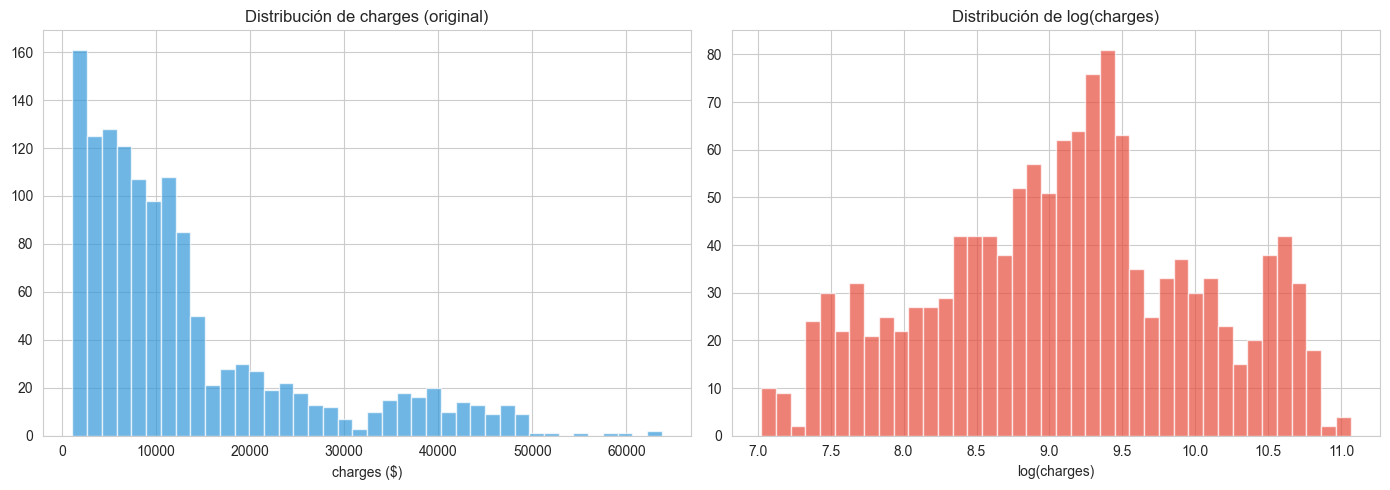

In [7]:
# Visualizar distribución antes/después de OHE para verificación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de charges (original vs log)
axes[0].hist(df_processed['charges'], bins=40, color='#3498db', alpha=0.7, label='Original')
axes[0].set_title('Distribución de charges (original)')
axes[0].set_xlabel('charges ($)')

axes[1].hist(df_processed['log_charges'], bins=40, color='#e74c3c', alpha=0.7, label='Log')
axes[1].set_title('Distribución de log(charges)')
axes[1].set_xlabel('log(charges)')

plt.tight_layout()
plt.savefig('../data/processed/target_transform_comparison.png', dpi=150)
plt.show()

## 5. División Train/Test

In [8]:
# ─────────────────────────────────────────
# SPLIT TRAIN / TEST (80/20)
# Estratificamos por smoker para balance
# ─────────────────────────────────────────
TARGET = 'log_charges'         # Usamos log para regresión lineal
TARGET_RAW = 'log_charges'     # Se puede cambiar a 'charges' para RF/KNN

# Features (excluimos targets)
FEATURES = [col for col in df_encoded.columns 
            if col not in ['log_charges']]

X = df_encoded[FEATURES]
y = df_encoded[TARGET]
y_raw = df_processed['charges']  # Para métricas en escala original

print(f'📊 Features utilizadas: {len(FEATURES)}')
print(f'📦 X shape: {X.shape}')
print(f'🎯 y shape: {y.shape}')

# Split estratificado por smoker
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
_, _, y_raw_train, y_raw_test = train_test_split(
    X, y_raw, test_size=0.2, random_state=42, shuffle=True
)

print(f'\n✅ Tamaños del split:')
print(f'  Train: {X_train.shape[0]} registros ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Test:  {X_test.shape[0]} registros ({len(X_test)/len(X)*100:.0f}%)')

📊 Features utilizadas: 19
📦 X shape: (1337, 19)
🎯 y shape: (1337,)

✅ Tamaños del split:
  Train: 1069 registros (80%)
  Test:  268 registros (20%)


## 6. Escalamiento de Variables Numéricas

In [9]:
# ─────────────────────────────────────────
# STANDARD SCALER
# Se ajusta SOLO sobre train, se aplica a test
# ─────────────────────────────────────────
num_features = ['age', 'bmi', 'children', 'bmi_smoker', 'age_smoker']
# Filtrar solo los que existen en el dataframe
num_features = [f for f in num_features if f in X_train.columns]

scaler = StandardScaler()

# Copias para escalar
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit sobre train, transform sobre ambos
X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

print('✅ Escalamiento aplicado correctamente')
print(f'   Features escaladas: {num_features}')

# Verificación: estadísticas post-scaling
print('\n📊 Verificación (train escalado):')
print(X_train_scaled[num_features].describe().round(4))

✅ Escalamiento aplicado correctamente
   Features escaladas: ['age', 'bmi', 'children', 'bmi_smoker', 'age_smoker']

📊 Verificación (train escalado):
             age        bmi   children  bmi_smoker  age_smoker
count  1069.0000  1069.0000  1069.0000   1069.0000   1069.0000
mean      0.0000     0.0000     0.0000      0.0000     -0.0000
std       1.0005     1.0005     1.0005      1.0005      1.0005
min      -1.5150    -2.4104    -0.9079     -0.4879     -0.4628
25%      -0.8718    -0.7208    -0.9079     -0.4879     -0.4628
50%      -0.0142    -0.0563    -0.0705     -0.4879     -0.4628
75%       0.8435     0.6430     0.7669     -0.4879     -0.4628
max       1.7726     3.7344     3.2791      3.7419      3.4199


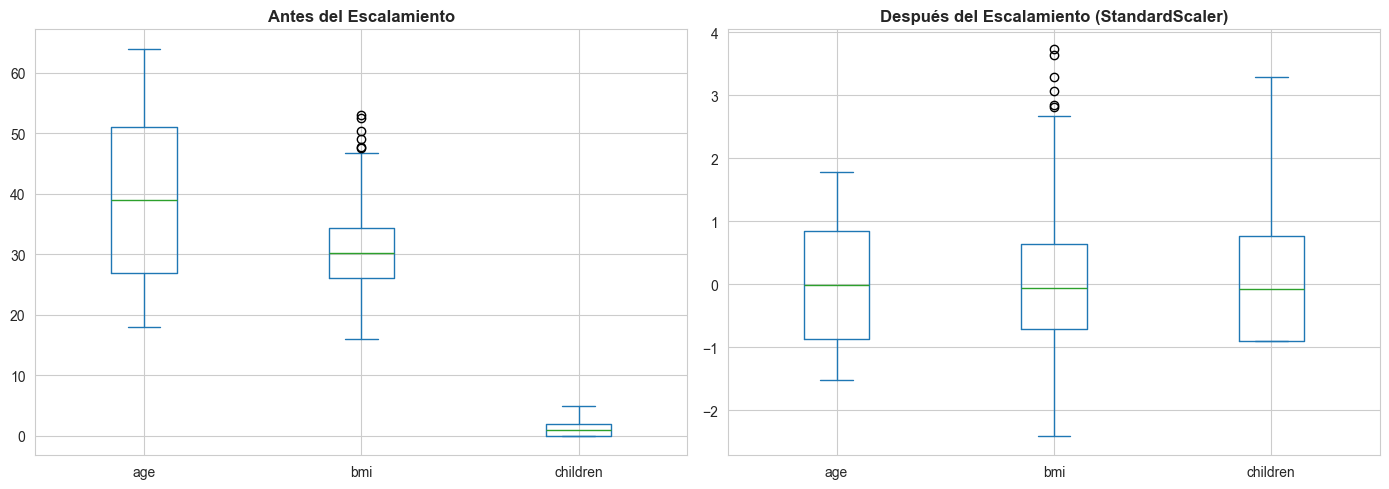

In [10]:
# Visualizar distribución antes/después del escalamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes del escalamiento
X_train[['age', 'bmi', 'children']].plot(kind='box', ax=axes[0])
axes[0].set_title('Antes del Escalamiento', fontweight='bold')

# Después del escalamiento
X_train_scaled[['age', 'bmi', 'children']].plot(kind='box', ax=axes[1])
axes[1].set_title('Después del Escalamiento (StandardScaler)', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/scaling_comparison.png', dpi=150)
plt.show()

## 7. Guardado de Artefactos

In [11]:
# ─────────────────────────────────────────
# GUARDAR DATASETS PROCESADOS
# ─────────────────────────────────────────
import os
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Guardar datasets para uso en otros notebooks
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)
y_raw_train.to_csv('../data/processed/y_raw_train.csv', index=False)
y_raw_test.to_csv('../data/processed/y_raw_test.csv', index=False)
df_processed.to_csv('../data/processed/insurance_processed.csv', index=False)

# Guardar feature list
import json
feature_info = {
    'all_features': list(FEATURES),
    'numeric_features': num_features,
    'target': TARGET,
    'n_features': len(FEATURES)
}
with open('../data/processed/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

# Guardar el scaler
joblib.dump(scaler, '../models/scaler.pkl')

print('✅ Artefactos guardados:')
print('  📁 data/processed/X_train.csv')
print('  📁 data/processed/X_test.csv')
print('  📁 data/processed/X_train_scaled.csv')
print('  📁 data/processed/X_test_scaled.csv')
print('  📁 data/processed/y_train.csv / y_test.csv')
print('  📁 data/processed/y_raw_train.csv / y_raw_test.csv')
print('  📁 data/processed/insurance_processed.csv')
print('  📁 data/processed/feature_info.json')
print('  📁 models/scaler.pkl')

✅ Artefactos guardados:
  📁 data/processed/X_train.csv
  📁 data/processed/X_test.csv
  📁 data/processed/X_train_scaled.csv
  📁 data/processed/X_test_scaled.csv
  📁 data/processed/y_train.csv / y_test.csv
  📁 data/processed/y_raw_train.csv / y_raw_test.csv
  📁 data/processed/insurance_processed.csv
  📁 data/processed/feature_info.json
  📁 models/scaler.pkl


## 8. Resumen Final del Preprocesamiento

In [1]:
print('='*60)
print('📊 RESUMEN DEL PREPROCESAMIENTO')
print('='*60)
print(f'  Registros originales:     {len(df)}')
print(f'  Registros procesados:     {len(df_processed)}')
print(f'  Features originales:      7')
print(f'  Features después de OHE:  {len(FEATURES)}')
print(f'  Train set:                {len(X_train)} registros')
print(f'  Test set:                 {len(X_test)} registros')
print(f'  Scaler:                   StandardScaler')
print(f'  Target:                   log(charges) para modelos lineales')
print()
print('📝 DECISIONES TOMADAS:')
print('  ✅ No se eliminaron outliers')
print('  ✅ One-Hot Encoding para sex, region, bmi_category, age_group')
print('  ✅ Label Encoding para smoker (binaria: 0/1)')
print('  ✅ StandardScaler para variables numéricas continuas')
print('  ✅ Transformación log1p en target para reducir sesgo')
print('  ✅ Features de interacción: bmi_smoker, age_smoker')
print('  ✅ Split 80/20 con random_state=42 para reproducibilidad')

📊 RESUMEN DEL PREPROCESAMIENTO


NameError: name 'df' is not defined